# <font color='darkblue'>*Marina Napoleão - EBAC*</font>
## <font color='darkblue'>Projeto Final de Modelos Avançados</font>

# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [1]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Bibliotecas para os modelos de machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

# Bibliotecas para métricas de avaliação
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from kneed import KneeLocator

In [3]:
df = pd.read_csv('Mall_Customers.csv', delimiter=',')
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

<font color='red'>1) Verificar os tipos de dados</font>

In [4]:
base = df.copy()
base.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [5]:
#excluir coluna categorica para não interferir no algoritmo Kmeans
base = base.drop(columns=['Gender'])

<font color='red'>2) Verificar os dados faltantes, se houver dados faltantes fazer a substituição ou remoção justificando sua escolha.</font>

In [6]:
print(base.info(), '\n número de valores faltantes em cada coluna: \n', base.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB
None 
 número de valores faltantes em cada coluna: 
 CustomerID                0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


* <font color='darkblue'> Nenhuma coluna possui dados faltantes. O dataset será mantido como se encontra.</font>

<font color='red'>3) Utilizar a função describe para verificar a distribuição dos dados.</font>

In [7]:
base.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


---------------

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

<font color='red'>4) Plotar graficos boxplot para identificar outliers e fazer o tratamento.</font>


 0.0 
 0.0 
 0.0 
 0.0


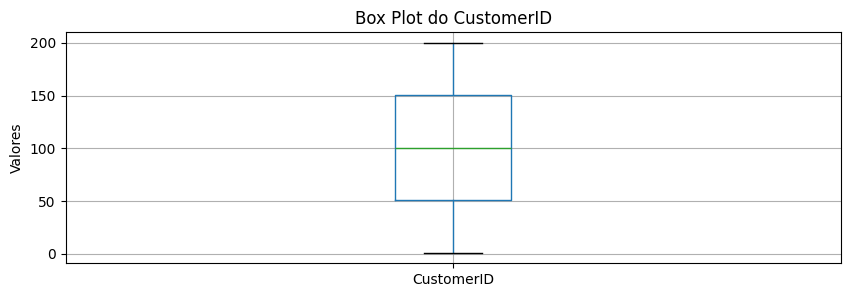

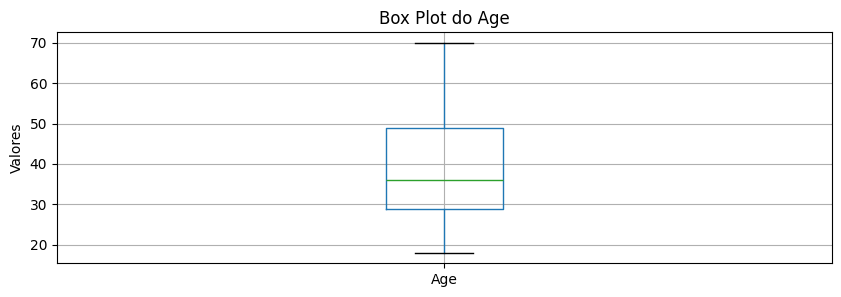

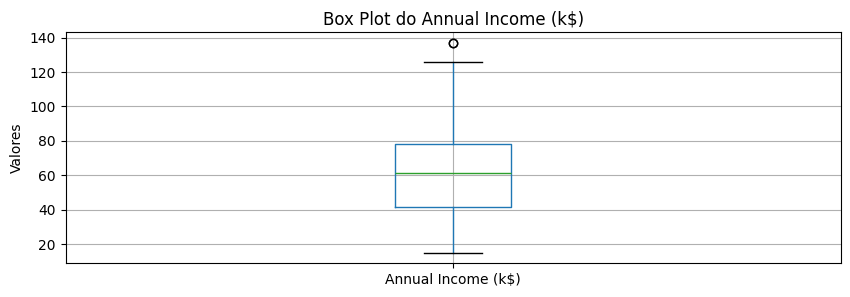

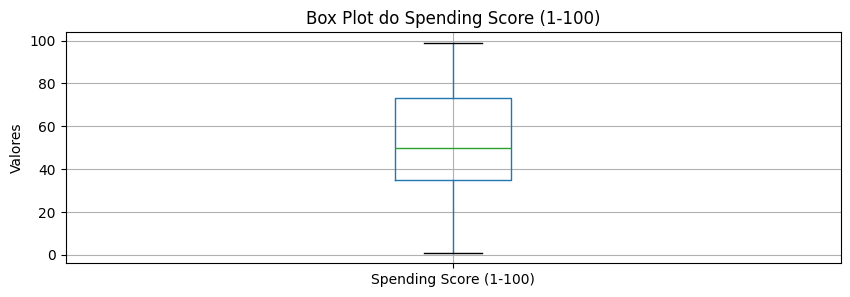

In [8]:
#média em porcentagem
a = (base['CustomerID'] == 0).mean() * 100
b = (base['Age'] == 0).mean() * 100
c = (base['Annual Income (k$)'] == 0).mean() * 100
d = (base['Spending Score (1-100)'] == 0).mean() * 100

print('\n', a, '\n', b, '\n', c, '\n', d)

#grafico boxplot do CustomerID
plt.figure(figsize=(10, 3))
base.boxplot(column='CustomerID')
plt.title('Box Plot do CustomerID')
plt.ylabel('Valores')
plt.show()

#grafico boxplot do Age
plt.figure(figsize=(10, 3))
base.boxplot(column='Age')
plt.title('Box Plot do Age')
plt.ylabel('Valores')
plt.show()

#grafico boxplot do Annual Income (k$)
plt.figure(figsize=(10, 3))
base.boxplot(column='Annual Income (k$)')
plt.title('Box Plot do Annual Income (k$)')
plt.ylabel('Valores')
plt.show()

#grafico boxplot do Spending Score (1-100)
plt.figure(figsize=(10, 3))
base.boxplot(column='Spending Score (1-100)')
plt.title('Box Plot do Spending Score (1-100)')
plt.ylabel('Valores')
plt.show()

In [9]:
coluna = 'Annual Income (k$)'

Q1 = base[coluna].quantile(0.25)
Q3 = base[coluna].quantile(0.75)
IRQ = Q3 - Q1

limite_inferior = Q1 - 1.5 * IRQ
limite_superior = Q3 + 1.5 * IRQ

print('\n Q1:', Q1, '\n Q3:', Q3, '\n IRQ:', IRQ)
print('\n Limite inferior:', limite_inferior)
print('\n Limite superior:', limite_superior)

outliers = base[(base[coluna] < limite_inferior) | (base[coluna] > limite_superior)]

impossiveis = base[(base[coluna] <= 0) | (base[coluna] > 133)]
print("total fixed acidity impossíveis:", impossiveis.shape[0])

print('\n Colunas analisadas:', coluna)
print('\n Total de outliers presente:', outliers.shape[0])


 Q1: 41.5 
 Q3: 78.0 
 IRQ: 36.5

 Limite inferior: -13.25

 Limite superior: 132.75
total fixed acidity impossíveis: 2

 Colunas analisadas: Annual Income (k$)

 Total de outliers presente: 2


In [10]:
# Visualizar apenas os Annual Income (k$) consideradas outliers pelo método IQR
outliers_annual = base[(base['Annual Income (k$)'] < limite_inferior) | (base['Annual Income (k$)'] > limite_superior)]
print(outliers_annual[['Annual Income (k$)']])

     Annual Income (k$)
198                 137
199                 137


In [11]:
base = base[base['Annual Income (k$)'] <= 132.5]

In [12]:
outliers = base[(base[coluna] < limite_inferior) | (base[coluna] > limite_superior)]
print(outliers)

Empty DataFrame
Columns: [CustomerID, Age, Annual Income (k$), Spending Score (1-100)]
Index: []


* <font color='darkblue'>A coluna 'Annual Income (k$)' revelou ter dois valores acima do limite superior calculado pelo método IQR. Esses valores influenciam negativamente em algoritmos como o K-means, pois causam, distorção na formação de clusters. Como esses valores extremos representam somente 1% dos dados, optei pela remoção deles.</font>

-------------

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

<font color='red'>5) Plotar o heatmap e indicar as variáveis que parecem mais "fortes" na correlação para o modelo</font>

In [13]:
#excluir coluna CustomerID para não interferir no heatmap
base = base.drop(columns=['CustomerID'])

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000            0.004406               -0.329421
Annual Income (k$)      0.004406            1.000000                0.010080
Spending Score (1-100) -0.329421            0.010080                1.000000


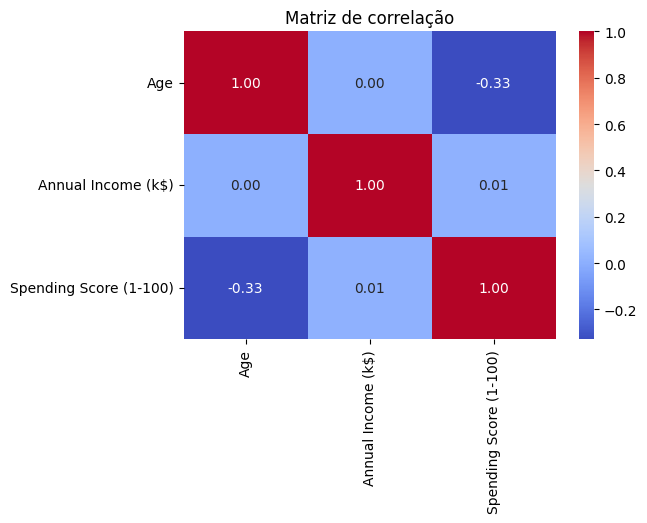

In [14]:
correlaçao = base.select_dtypes(include = ['number']).corr()
print(correlaçao)

correlation_matrix1 = base.select_dtypes(include = ['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize = (6, 4))
sns.heatmap(correlation_matrix1, annot = True, cmap = 'coolwarm', fmt = ".2f", annot_kws = {"size": 10})
plt.title('Matriz de correlação')
plt.show()

* <font color='darkblue'>Como esperado, vimos por meio da análise do mapa que renda e pontuação de gastos não têm correlação linear direta, reforçando a ideia do uso de métodos como K-means.</font>

<font color='darkblue'>→ Correlação nula (0.00): Age & Annual Income</font>

<font color='darkblue'>→ Correlação fraca/praticamente inexistente (0.01): Annual Income & Spending Score</font>

<font color='darkblue'>→ Correlação negativa moderada (-0.33): Age & Spending Score</font>

<font color='red'>6) Visualizear a análise descritiva dos dados utilizando a função pairplot.</font>

In [15]:
base = base.reset_index(drop=True)

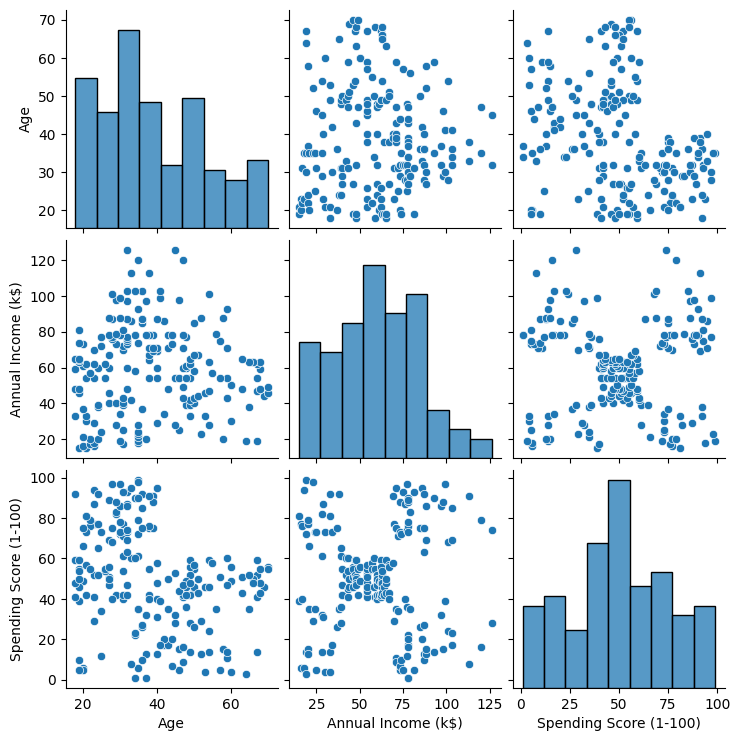

In [16]:
sns.pairplot(base)

In [17]:
#Annual Income & Spending Score
fig = px.scatter(base, x='Annual Income (k$)', y='Spending Score (1-100)',
                 title='Gráfico de Dispersão: Annual Income (k$) vs. Spending Score (1-100) | Forte correlação positiva',
                 labels={'Annual Income (k$)': 'Annual Income (k$)', 'Spending Score (1-100)': 'Spending Score (1-100)'})
fig.show()

#Age & Spending Score
fig = px.scatter(base, x='Age', y='Spending Score (1-100)',
                 title='Gráfico de Dispersão: Age vs. Spending Score (1-100) | Forte correlação negativa',
                 labels={'Age': 'Age', 'Spending Score (1-100)': 'Spending Score (1-100)'})
fig.show()

--------------

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

In [18]:
base_padronizado = base.copy()

In [19]:
colunas_padronizar =['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

x = base_padronizado[colunas_padronizar].values

# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
x_scaled = scaler.fit_transform(x)

In [20]:
inercia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(x_scaled)
    inercia.append(kmeans.inertia_)

K ideal encontrado automaticamente: 4


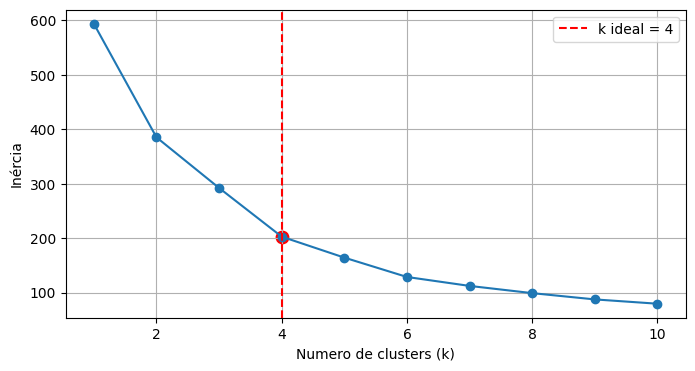

In [21]:
# Encontrar o cotovelo automaticamente
kneedle = KneeLocator(K, inercia, curve = 'convex', direction = 'decreasing')
k_ideal = kneedle.elbow
print("K ideal encontrado automaticamente:", k_ideal)

plt.figure(figsize=(8,4))
plt.plot(K,inercia, marker='o')

plt.axvline(x=k_ideal, color='red', linestyle='--', label=f'k ideal = {k_ideal}')  # linha vertical marcando o k ideal
plt.scatter(k_ideal, inercia[k_ideal - 1], color='red', s=80)   # ponto marcado no gráfico

plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inércia')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Aplicar o algoritmo do kmeans
kmeans_base = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_base.fit(x_scaled)

#criar os labels dos grupos
labels = kmeans_base.labels_

# Centroides padronizados retornados pelo k-means
centroides_padronizados = kmeans_base.cluster_centers_ 

# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)

print('\n centroides_padronizados:',centroides_padronizados)
print('\n centroides_originais:',centroides_originais)
print('\n labels:',labels)


 centroides_padronizados: [[ 1.07680996 -0.47987811 -0.39824935]
 [-0.4277519   0.99338768  1.21838324]
 [-0.96490237 -0.78606152  0.39332511]
 [ 0.04565166  1.00690444 -1.19054784]]

 centroides_originais: [[53.98461538 47.70769231 39.96923077]
 [32.94871795 84.79487179 81.48717949]
 [25.43859649 40.         60.29824561]
 [39.56756757 85.13513514 19.62162162]]

 labels: [2 2 2 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 3 2 2 2 0 0 0 0 2 3 1 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1]


<font color='darkblue'>Considerando a ordem das colunas sendo Age, Annual Income (k$), Spending Score (1-100):

* <font color='darkblue'>Cluster 0: Age → 54, Annual Income → 47.700, Spending Score → 40</font>
<font color='darkblue'>Adultos (perto da terceira idade) com renda média e gastos médio/baixo.</font>

* <font color='darkblue'>Cluster 1: Age → 33, Annual Income → 84.800, Spending Score → 81.5</font>
<font color='darkblue'>Adultos com renda alta e alto gasto | melhores clientes (prioridade)</font>

* <font color='darkblue'>Cluster 2: Age → 25, Annual Income → 40.000, Spending Score → 60.3</font>
<font color='darkblue'>Jovens (início da fase adulta) com renda menor, porém com bom número de gastos.</font>

* <font color='darkblue'>Cluster 3: Age → 39, Annual Income → 85.100, Spending Score → 19.6</font>
<font color='darkblue'>Adultos (meia-idade) com alta renda e baixo gasto | clientes com alto potencial não realizado.</font>

In [23]:
base_padronizado['cluster'] = labels
print(base_padronizado['cluster'].value_counts())
print(base_padronizado.groupby('cluster')[colunas_padronizar].mean())

cluster
0    65
2    57
1    39
3    37
Name: count, dtype: int64
               Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                       
0        53.984615           47.707692               39.969231
1        32.948718           84.794872               81.487179
2        25.438596           40.000000               60.298246
3        39.567568           85.135135               19.621622


Matriz 1 - Pairplot: Annual Income (k$) vs Spending Score (1-100)


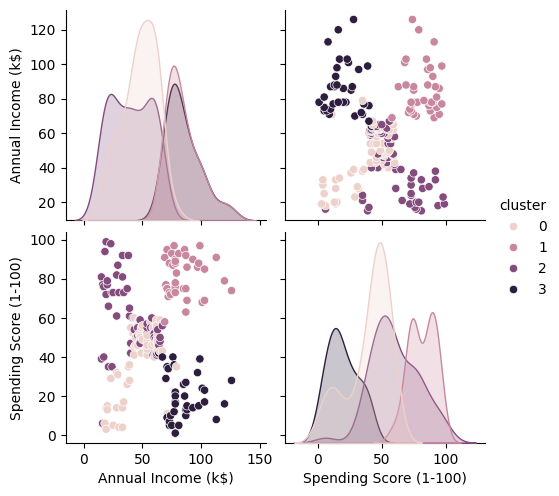

In [24]:
print('Matriz 1 - Pairplot: Annual Income (k$) vs Spending Score (1-100)')
sns.pairplot(base_padronizado[['Annual Income (k$)', 'Spending Score (1-100)', 'cluster']], hue='cluster')

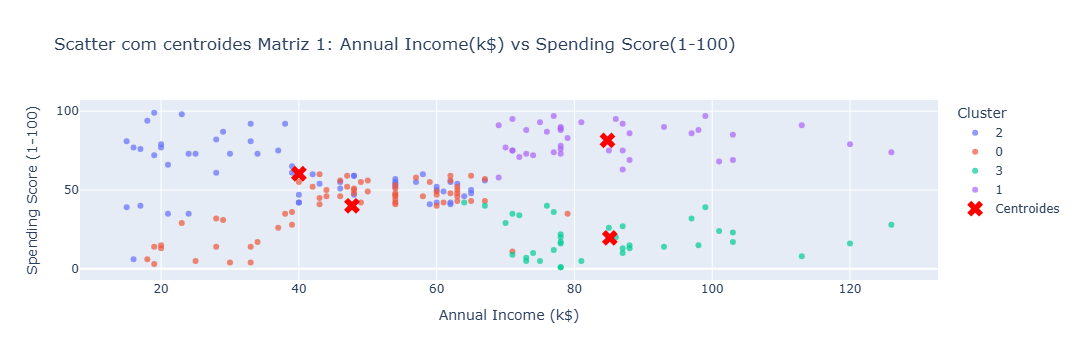

In [25]:
# seu código aqui
base_clusters = pd.DataFrame({
    'Annual Income (k$)': base['Annual Income (k$)'],
    'Spending Score (1-100)': base['Spending Score (1-100)'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Scatter com centroides Matriz 1: Annual Income(k$) vs Spending Score(1-100)')

fig.add_scatter(x = centroides_originais[:, 1],  # Annual Income
                y = centroides_originais[:, 2],  # Spending
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Annual Income (k$)', yaxis_title='Spending Score (1-100)',
                  legend_title='Cluster')
fig.show()

Matriz 2 - Pairplot: Age vs Spending Score (1-100)


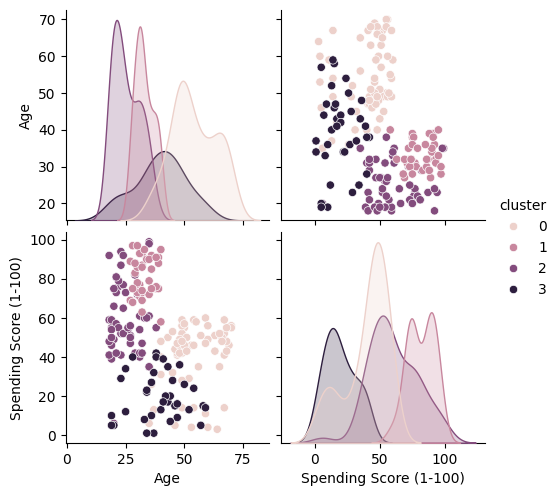

In [26]:
print('Matriz 2 - Pairplot: Age vs Spending Score (1-100)')
sns.pairplot(base_padronizado[['Age', 'Spending Score (1-100)', 'cluster']], hue='cluster')

In [27]:
# seu código aqui
base_clusters = pd.DataFrame({
    'Age': base['Age'],
    'Spending Score (1-100)': base['Spending Score (1-100)'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='Age', y='Spending Score (1-100)', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Scatter com centroides Matriz 2: Age vs Spending Score (1-100)')

fig.add_scatter(x = centroides_originais[:, 0],  # Age
                y = centroides_originais[:, 2], # Spending
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Age', yaxis_title='Spending Score (1-100)',
                  legend_title='Cluster')
fig.show()

In [30]:
sil= silhouette_score(x_scaled, labels) #O silhouette ajuda a ver qual K gera os clustere mais bem separados.
db = davies_bouldin_score(x_scaled, labels) #O davies-bouldin mede o quão espalhados estão os clusters
print('Silhouette:', sil)
print('Davies-Bouldin:', db)

silhouette: 0.4233270599518335
Davies-Bouldin: 0.8559675814772115


k = 2, silhouette = 0.3341
k = 3, silhouette = 0.3188
k = 4, silhouette = 0.4057
k = 5, silhouette = 0.4121
k = 6, silhouette = 0.4373
k = 7, silhouette = 0.4129
k = 8, silhouette = 0.4124
k = 9, silhouette = 0.4210
k = 10, silhouette = 0.4233


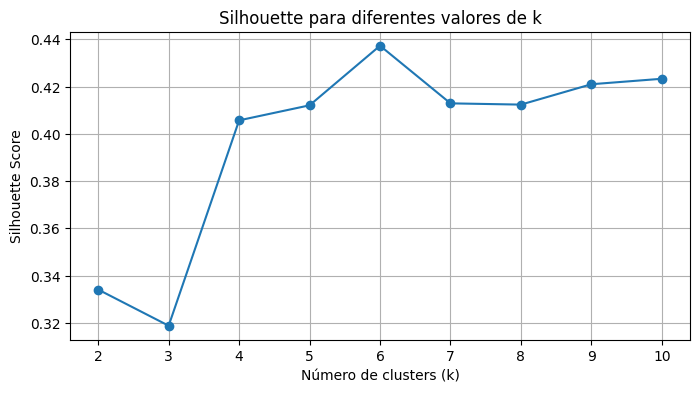

In [31]:
sil_scores = []
K = range(2, 11)  # começa em 2 porque silhouette não é definido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    sil_scores.append(score)
    print(f'k = {k}, silhouette = {score:.4f}')

# Plotar
plt.figure(figsize=(8, 4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette para diferentes valores de k')
plt.xticks(K)
plt.grid(True)
plt.show()

<font color='darkblue'>As métricas de validação () sugerem uma separação eficaz entre os clusters e uma estrutura de agrupamento consistente. Isso confirma que a escolha de k = 4 resulta em clusters estáveis, bem definidos e apropriados para a segmentação de clientes.</font>

* <font color='darkblue'>Silhouette (k=4): 0.4057 → Boa separação, clusterização estável.</font>
* <font color='darkblue'>DBI (k=4): 0.8559 → Clusters bem definidos.</font>